In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
# angle bounds for determining cis vs trans configurations

cislower = -90
cisupper = 50
translower = 100
transupper = 240

nsim = 10 # number of simulations

In [3]:
ctd_weights_combined_raw = pd.read_table('/data/mcohen3/CTD/asparagine/s5n7/reweighting/weights_by_frame_MC-order10.dat', header=None)
p_ctd_weights_combined_raw = pd.read_table('/data/mcohen3/CTD/asparagine/ps5n7/reweighting/weights_by_frame_MC-order10.dat', header=None)

In [4]:
ctd_weights_combined = ctd_weights_combined_raw/ctd_weights_combined_raw.sum()
p_ctd_weights_combined = p_ctd_weights_combined_raw/p_ctd_weights_combined_raw.sum()

In [5]:
params = [{'sep':r'\s+', 'low_memory':False}, {'engine':'c'}][0]

SASA_unphos = pd.read_table('/data/mcohen3/CTD/asparagine/s5n7/analysis/hbonds/dat/surf.dat', **params)
SASA_phos = pd.read_table('/data/mcohen3/CTD/asparagine/ps5n7/analysis/hbonds/dat/surf.dat', **params)

In [6]:
ctd_phos_omega_angles_raw = pd.read_table('/data/mcohen3/CTD/asparagine/ps5n7/analysis/turn/ctd_dihedral_Omega.dat', header=0, sep = r'\s+')
ctd_unphos_omega_angles_raw = pd.read_table('/data/mcohen3/CTD/asparagine/s5n7/analysis/turn/ctd_dihedral_Omega.dat', header=0, sep = r'\s+')

In [23]:
def weighted_mean_and_se(values, weights):
    """
    Calculates the weighted mean and its standard error.

    Args:
        values (array-like): The data values.
        weights (array-like): The corresponding weights for each value.

    Returns:
        tuple: A tuple containing the weighted mean and the standard error of the weighted mean.
    """
    values = np.array(values)
    weights = np.array(weights)

    if len(values) != len(weights):
        raise ValueError("Values and weights must have the same length.")

    # Create a boolean mask to find non-NaN values in both data and weights.
    valid_mask = ~np.isnan(values) & ~np.isnan(weights)
    
    # Filter the data and weights to keep only valid entries.
    valid_data = values[valid_mask]
    valid_weights = weights[valid_mask]

    # Calculate the weighted mean
    weighted_mean = np.average(valid_data, weights=valid_weights)

    # Calculate the weighted variance
    # For sample variance, adjust for degrees of freedom (n-1)
    # The denominator for weighted variance is typically sum(weights) - (sum(weights^2) / sum(weights))
    # or a simpler form for large samples. Here we use a common form for sample weighted variance.
    sum_of_weights = np.sum(valid_weights)
    weighted_variance = np.sum(valid_weights * (valid_data - weighted_mean)**2) / (sum_of_weights - (np.sum(valid_weights**2) / sum_of_weights))

    # Calculate the standard error of the weighted mean
    # SE = sqrt(weighted_variance / effective_sample_size)
    # Effective sample size can be considered as (sum_of_weights)^2 / sum(weights^2)
    effective_sample_size = (sum_of_weights**2) / np.sum(valid_weights**2)
    standard_error = np.sqrt(weighted_variance / effective_sample_size)

    return weighted_mean, standard_error

In [7]:
df_360_phos = ctd_phos_omega_angles_raw # Create a new column to hold the 360-degree adjusted omega values
# loop through columns to convert numbers below -90
for col in df_360_phos:
    df_360_phos.loc[df_360_phos[col] < -90, col] += 360  # Convert negative angles to a 0-360 range
    df_360_phos[col] = round(df_360_phos[col])  # Round angles to the nearest integer

df_360_unphos = ctd_unphos_omega_angles_raw # Create a new column to hold the 360-degree adjusted omega values
# loop through columns to convert numbers below -90
for col in df_360_unphos:
    df_360_unphos.loc[df_360_unphos[col] < -90, col] += 360  # Convert negative angles to a 0-360 range
    df_360_unphos[col] = round(df_360_unphos[col])  # Round angles to the nearest integer

In [8]:
# retaining omega angle values
ctd_phos_omega_angles = df_360_phos.copy()
ctd_unphos_omega_angles = df_360_unphos.copy()

In [9]:
# labelling configurationgs of omega angles
temp_angles = ctd_phos_omega_angles.copy()

ctd_phos_omega_angles[(temp_angles.iloc[:,1:] >= cislower) & (temp_angles.iloc[:,1:] <= cisupper)] = "cis"
ctd_phos_omega_angles[(temp_angles.iloc[:,1:] >= translower) & (temp_angles.iloc[:,1:] <= transupper)] = "trans"
ctd_phos_omega_angles[(ctd_phos_omega_angles.iloc[:,1:] != "cis") & (ctd_phos_omega_angles.iloc[:,1:] != "trans")] = "neither"

# labelling configurationgs of omega angles
temp_angles = ctd_unphos_omega_angles.copy()

ctd_unphos_omega_angles[(temp_angles.iloc[:,1:] >= cislower) & (temp_angles.iloc[:,1:] <= cisupper)] = "cis"
ctd_unphos_omega_angles[(temp_angles.iloc[:,1:] >= translower) & (temp_angles.iloc[:,1:] <= transupper)] = "trans"
ctd_unphos_omega_angles[(ctd_unphos_omega_angles.iloc[:,1:] != "cis") & (ctd_unphos_omega_angles.iloc[:,1:] != "trans")] = "neither"

/tmp/ipykernel_1060045/3533782883.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'cis' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  ctd_phos_omega_angles[(temp_angles.iloc[:,1:] >= cislower) & (temp_angles.iloc[:,1:] <= cisupper)] = "cis"
/tmp/ipykernel_1060045/3533782883.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'cis' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  ctd_unphos_omega_angles[(temp_angles.iloc[:,1:] >= cislower) & (temp_angles.iloc[:,1:] <= cisupper)] = "cis"


In [10]:
SASA_phos.head()

,#Frame,SA_00001,SA_00002,SA_00003,SA_00004,SA_00005,SA_00006,SA_00007,SA_00008,SA_00009,...,SA_00015,SA_00016,SA_00017,SA_00018,SA_00019,SA_00020,SA_00021,SA_00022,SA_00023,SA_00024
0,1,2157.0936,55.4316,132.7084,28.2503,40.9313,123.6935,177.2314,110.4554,43.2490,...,93.0831,3.4550,125.2042,56.7199,75.2378,128.1682,188.7835,104.1303,134.5105,28.7778
1,2,2163.5888,54.9531,127.7529,31.3534,45.8853,129.1535,177.5830,111.7335,48.5059,...,92.6687,5.1607,130.2965,57.2949,81.3542,124.4263,177.2200,101.3794,140.0929,23.3432
2,3,2165.5688,62.8375,126.5708,33.6164,41.8252,124.3157,178.5122,112.9273,55.3413,...,87.5836,9.1339,136.3379,53.1979,74.3822,125.4005,172.8945,102.1190,135.2781,18.0012
3,4,2175.2677,66.5181,131.0680,30.1599,38.4660,126.0034,185.1882,115.9002,54.3483,...,88.4040,5.2275,134.9295,57.9735,71.0334,124.5026,171.1479,104.4626,131.1285,26.5571
4,5,2176.4163,69.7015,131.9024,28.5254,38.5168,121.1518,179.9742,114.8958,48.7966,...,86.4911,4.3458,127.8432,65.0637,73.6963,125.0431,176.6282,103.3776,129.7348,32.2600


In [11]:
ser5_SASA_unphos = pd.DataFrame(SASA_unphos['SA_00014'])
ser5_SASA_phos = pd.DataFrame(SASA_phos['SA_00014'])

In [12]:
ser5_SASA_phos = ser5_SASA_phos.reset_index(drop=True)
ser5_SASA_phos_cistrans = ser5_SASA_phos.copy()
ser5_SASA_phos_cistrans['cis/trans/neither'] = ctd_phos_omega_angles['omega:14']

ser5_SASA_unphos = ser5_SASA_unphos.reset_index(drop=True)
ser5_SASA_unphos_cistrans = ser5_SASA_unphos.copy()
ser5_SASA_unphos_cistrans['cis/trans/neither'] = ctd_unphos_omega_angles['omega:14']

In [13]:
ser5_SASA_unphos_cistrans['weights'] = ctd_weights_combined[0]
ser5_SASA_phos_cistrans['weights'] = p_ctd_weights_combined[0]

In [14]:
ser5_SASA_unphos_cistrans

,SA_00014,cis/trans/neither,weights
0,111.4741,trans,5.568765e-09
1,113.6700,trans,1.472184e-08
2,114.8034,trans,9.697759e-09
3,114.2768,trans,3.353217e-08
4,112.1722,trans,8.338822e-09
...,...,...,...
48999995,97.7749,trans,1.317516e-08
48999996,98.6006,trans,1.811567e-08
48999997,99.5379,trans,3.887373e-08
48999998,100.7151,trans,2.536682e-08


In [15]:
SASA_sim_list = np.array_split(ser5_SASA_unphos_cistrans, nsim)
phos_SASA_sim_list = np.array_split(ser5_SASA_phos_cistrans, nsim)

/cm/shared/apps/anaconda3/python3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


# Phosphorylated

## Pro6 in cis

In [16]:
pmean_cis = np.average((ser5_SASA_phos_cistrans[ser5_SASA_phos_cistrans['cis/trans/neither'] == 'cis'])['SA_00014'], weights=(ser5_SASA_phos_cistrans[ser5_SASA_phos_cistrans['cis/trans/neither'] == 'cis'])['weights'])

pstd_cis = np.sqrt(np.cov((ser5_SASA_phos_cistrans[ser5_SASA_phos_cistrans['cis/trans/neither'] == 'cis'])['SA_00014'], aweights=(ser5_SASA_phos_cistrans[ser5_SASA_phos_cistrans['cis/trans/neither'] == 'cis'])['weights']))

print("pmean: {}".format(pmean_cis))
print("pstd: {}".format(pstd_cis))

pmean: 181.27427930259256
pstd: 19.968330402883012


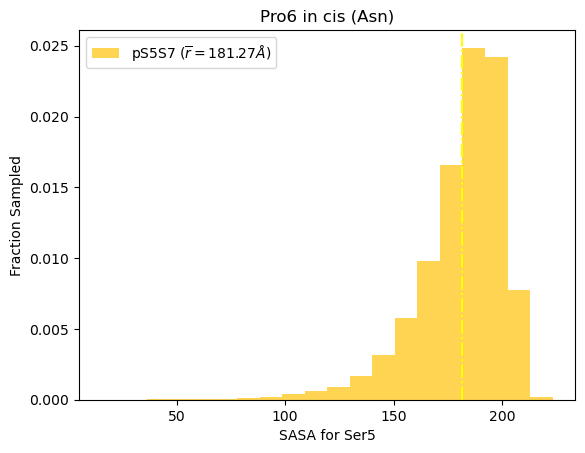

In [17]:
plt.hist((ser5_SASA_phos_cistrans[ser5_SASA_phos_cistrans['cis/trans/neither'] == 'cis'])['SA_00014'], bins=20, weights = (ser5_SASA_phos_cistrans[ser5_SASA_phos_cistrans['cis/trans/neither'] == 'cis'])['weights'], density=True , color="#FFC20A", label=r"pS5S7 ($\overline{r} = $"+"{}$\AA$)".format(round(pmean_cis, 2)), alpha=0.7)

#plt.axvline(npmean, color='steelblue', ls='--')
plt.axvline(pmean_cis, color='yellow', ls='-.')
#plt.ylim([0, 0.45])
#plt.xlim([3,8])
# plt.text(15.5, 0.24, r"$\overline{r_{phos}}=$" + str(round(pmean, 3)), fontsize=9, horizontalalignment='right')
# plt.text(15.5, 0.255, r"$\overline{r_{unphos}}=$" + str(round(npmean, 2)), fontsize=9, horizontalalignment='right')

#plt.axvline(ctd['1-23'].mean(), color='k', linestyle='solid', linewidth=1, label = "CTD mean")
#plt.axvline(ctd_cisp['1-23'].mean(), color='k', linestyle='dotted', linewidth=1, label = "CTD Phos mean")
plt.ylabel('Fraction Sampled')
plt.xlabel('SASA for Ser5')
plt.title('Pro6 in cis (Asn)')
plt.legend(loc="upper left", fontsize=10)
plt.show()

## Pro6 in trans

In [18]:
pmean_trans = np.average((ser5_SASA_phos_cistrans[ser5_SASA_phos_cistrans['cis/trans/neither'] == 'trans'])['SA_00014'], weights=(ser5_SASA_phos_cistrans[ser5_SASA_phos_cistrans['cis/trans/neither'] == 'trans'])['weights'])

pstd_trans = np.sqrt(np.cov((ser5_SASA_phos_cistrans[ser5_SASA_phos_cistrans['cis/trans/neither'] == 'trans'])['SA_00014'], aweights=(ser5_SASA_phos_cistrans[ser5_SASA_phos_cistrans['cis/trans/neither'] == 'trans'])['weights']))

print("pmean: {}".format(pmean_trans))
print("pstd: {}".format(pstd_trans))

pmean: 172.2918057330975
pstd: 24.56641201352292


In [19]:
# Define column names
columns = ['cis', 'trans']

# Create an empty DataFrame with 2 rows and 5 columns
phos_SASA_all = pd.DataFrame(np.nan, index=range(nsim), columns=columns)
phos_SASA_weights = pd.DataFrame(np.nan, index=range(nsim), columns=columns)

print(phos_SASA_all)

   cis  trans
0  NaN    NaN
1  NaN    NaN
2  NaN    NaN
3  NaN    NaN
4  NaN    NaN
5  NaN    NaN
6  NaN    NaN
7  NaN    NaN
8  NaN    NaN
9  NaN    NaN


In [21]:
i = 0
for sim in phos_SASA_sim_list:
    cis_true = ((sim['cis/trans/neither'] == 'cis')*sim['weights']).sum()
    trans_true = ((sim['cis/trans/neither'] == 'trans')*sim['weights']).sum()

    mean = sim['SA_00014'].mul((sim['cis/trans/neither'] == 'cis')*sim['weights'], 0).sum()/cis_true
    phos_SASA_all.at[i, 'cis'] = mean
    phos_SASA_weights.at[i, 'cis'] = cis_true
    mean = sim['SA_00014'].mul((sim['cis/trans/neither'] == 'trans')*sim['weights'], 0).sum()/trans_true
    phos_SASA_all.at[i, 'trans'] = mean
    phos_SASA_weights.at[i, 'trans'] = trans_true
    
    i += 1

In [24]:
mean_list = []
sem_list = []
for i in range(2):
    print(i)
    mean_list.append(weighted_mean_and_se(phos_SASA_all.iloc[:,i].tolist(), phos_SASA_weights.iloc[:,i].tolist())[0])
    sem_list.append(weighted_mean_and_se(phos_SASA_all.iloc[:,i].tolist(), phos_SASA_weights.iloc[:,i].tolist())[1])

0
1


In [25]:
df_with_mean = pd.concat([phos_SASA_all, pd.DataFrame([mean_list], index=['mean'], columns=columns)])
phos_SASA_all_final = pd.concat([df_with_mean, pd.DataFrame([sem_list], index=['sem'], columns=columns)])

In [41]:
phos_SASA_all_final

,cis,trans
0,175.382849,169.744788
1,179.363805,170.231473
2,181.200101,167.919145
3,174.965169,167.278991
4,179.009961,169.929187
5,185.354742,176.624524
6,183.513304,175.808741
7,185.339024,177.881550
8,185.271179,174.277493
9,183.283698,174.705250


In [27]:
# Original data and weights
group1_data = phos_SASA_all['cis']
group1_weights = phos_SASA_weights['cis']

group2_data = phos_SASA_all['trans']
group2_weights = phos_SASA_weights['trans']

# Normalize the weights
group1_p = group1_weights / np.sum(group1_weights)
group2_p = group2_weights / np.sum(group2_weights)

# Calculate the observed difference in means
original_diff_means = pmean_cis - pmean_trans

num_iterations = 1000000

# Vectorized resampling
# Draws num_iterations samples of size len(data) in a single operation
resampled_g1 = np.random.choice(group1_data, size=(num_iterations, len(group1_data)), replace=True, p=group1_p)
resampled_g2 = np.random.choice(group2_data, size=(num_iterations, len(group2_data)), replace=True, p=group2_p)

# Calculate the mean for each resampled group along the rows (axis=1)
means_g1 = np.mean(resampled_g1, axis=1)
means_g2 = np.mean(resampled_g2, axis=1)

# Calculate the difference in means for all samples at once
diff_means_samples = means_g1 - means_g2

# Calculate the p-value
p_value = np.sum(np.abs(diff_means_samples) >= np.abs(original_diff_means)) / num_iterations

print(f"Original difference in means: {original_diff_means}")
print(f"Calculated P-value from vectorized permutation test: {p_value}")

Original difference in means: 8.982473569495056
Calculated P-value from vectorized permutation test: 0.504627


In [42]:
# Original data and weights
group1_data = phos_SASA_all['cis']
group1_weights = phos_SASA_weights['cis']

group2_data = phos_SASA_all['trans']
group2_weights = phos_SASA_weights['trans']

both_groups = pd.concat([group1_data, group2_data], ignore_index=True)
both_weights = pd.concat([group1_weights, group2_weights], ignore_index=True)

# Normalize the weights
both_p = both_weights / np.sum(both_weights)

# Calculate the observed statistic on the original data using the MEAN
original_diff_means = pmean_cis - pmean_trans

num_sims = 10
#sample 10000 times and calculate differences
numsample = 10000
diff_samples = [0]*numsample
diff_samples_larger = [0]*numsample
for sample in range(0,len(diff_samples)):
    # randomize means and weights arrays in the same order
    p = np.random.permutation(len(both_groups))
    random_both_groups = both_groups[p]
    random_weights = both_p[p]
    diff_samples[sample] = (np.average(random_both_groups[0:num_sims], weights=random_weights[0:num_sims]) 
             - np.average(random_both_groups[num_sims:num_sims + num_sims], weights=random_weights[num_sims:num_sims + num_sims]))
    if diff_samples[sample] >= original_diff_means:
        diff_samples_larger[sample] = 1
    
# Calculate the p-value
p_value = (1 + np.sum(diff_samples_larger))/(numsample + 1)

print(f"Original difference in means: {original_diff_means}")
print(f"Calculated P-value from permutation test: {p_value}")

Original difference in means: 8.982473569495056
Calculated P-value from permutation test: 9.999000099990002e-05


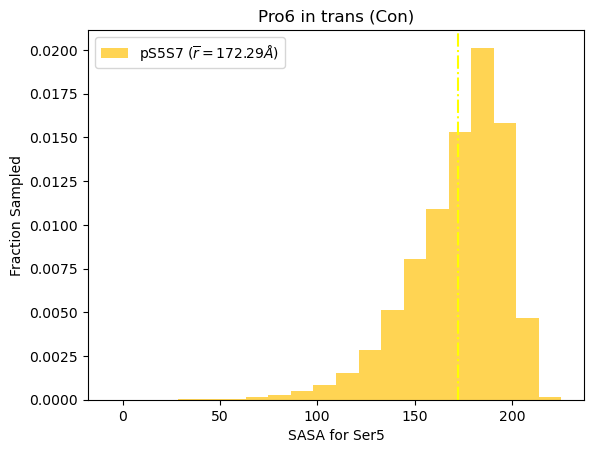

In [28]:
plt.hist((ser5_SASA_phos_cistrans[ser5_SASA_phos_cistrans['cis/trans/neither'] == 'trans'])['SA_00014'], bins=20, weights = (ser5_SASA_phos_cistrans[ser5_SASA_phos_cistrans['cis/trans/neither'] == 'trans'])['weights'], density=True , color="#FFC20A", label=r"pS5S7 ($\overline{r} = $"+"{}$\AA$)".format(round(pmean_trans, 2)), alpha=0.7)

#plt.axvline(npmean, color='steelblue', ls='--')
plt.axvline(pmean_trans, color='yellow', ls='-.')
#plt.ylim([0, 0.45])
#plt.xlim([3,8])
# plt.text(15.5, 0.24, r"$\overline{r_{phos}}=$" + str(round(pmean, 3)), fontsize=9, horizontalalignment='right')
# plt.text(15.5, 0.255, r"$\overline{r_{unphos}}=$" + str(round(npmean, 2)), fontsize=9, horizontalalignment='right')

#plt.axvline(ctd['1-23'].mean(), color='k', linestyle='solid', linewidth=1, label = "CTD mean")
#plt.axvline(ctd_cisp['1-23'].mean(), color='k', linestyle='dotted', linewidth=1, label = "CTD Phos mean")
plt.ylabel('Fraction Sampled')
plt.xlabel('SASA for Ser5')
plt.title('Pro6 in trans (Con)')
plt.legend(loc="upper left", fontsize=10)
plt.show()

## cis and trans together

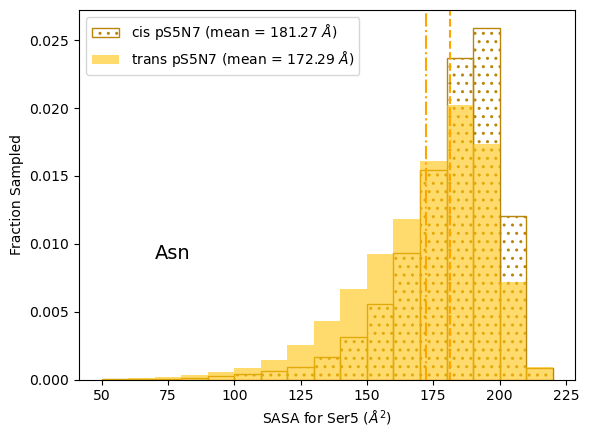

In [47]:
binedges = np.arange(50,225,10)

plt.figure()
plt.hist((ser5_SASA_phos_cistrans[ser5_SASA_phos_cistrans['cis/trans/neither'] == 'cis'])['SA_00014'], bins=binedges, weights = (ser5_SASA_phos_cistrans[ser5_SASA_phos_cistrans['cis/trans/neither'] == 'cis'])['weights'], density=True, edgecolor="darkgoldenrod", color = '#FFC20A', fill=None, hatch='..', label=r"cis pS5N7 (mean = "+"{} $\AA$)".format(round(pmean_cis, 2)), alpha=1)

#plt.axvline(npmean, color='steelblue', ls='--')
plt.axvline(pmean_cis, color='orange', ls='--')
#plt.ylim([0, 0.45])
#plt.xlim([3,8])
# plt.text(15.5, 0.24, r"$\overline{r_{phos}}=$" + str(round(pmean, 3)), fontsize=9, horizontalalignment='right')
# plt.text(15.5, 0.255, r"$\overline{r_{unphos}}=$" + str(round(npmean, 2)), fontsize=9, horizontalalignment='right')
plt.hist((ser5_SASA_phos_cistrans[ser5_SASA_phos_cistrans['cis/trans/neither'] == 'trans'])['SA_00014'], bins=binedges, weights = (ser5_SASA_phos_cistrans[ser5_SASA_phos_cistrans['cis/trans/neither'] == 'trans'])['weights'], density=True , color="#FFC20A", label=r"trans pS5N7 (mean = "+"{} $\AA$)".format(round(pmean_trans, 2)), alpha=0.6)

#plt.axvline(npmean, color='steelblue', ls='--')
plt.axvline(pmean_trans, color='orange', ls='-.')

#plt.axvline(ctd['1-23'].mean(), color='k', linestyle='solid', linewidth=1, label = "CTD mean")
#plt.axvline(ctd_cisp['1-23'].mean(), color='k', linestyle='dotted', linewidth=1, label = "CTD Phos mean")
plt.ylabel('Fraction Sampled')
plt.xlabel('SASA for Ser5 ($\AA^{2}$)')
#plt.title('Asparagine Phosphorylated')
plt.legend(loc="upper left", fontsize=10)
plt.text(70, 0.01, 'Asn', fontsize=14, verticalalignment='top')
plt.show()

# Unphosphorylated

## Pro6 in cis

In [30]:
mean_cis = np.average((ser5_SASA_unphos_cistrans[ser5_SASA_unphos_cistrans['cis/trans/neither'] == 'cis'])['SA_00014'], weights=(ser5_SASA_unphos_cistrans[ser5_SASA_unphos_cistrans['cis/trans/neither'] == 'cis'])['weights'])

std_cis = np.sqrt(np.cov((ser5_SASA_unphos_cistrans[ser5_SASA_unphos_cistrans['cis/trans/neither'] == 'cis'])['SA_00014'], aweights=(ser5_SASA_unphos_cistrans[ser5_SASA_unphos_cistrans['cis/trans/neither'] == 'cis'])['weights']))

print("mean: {}".format(mean_cis))
print("std: {}".format(std_cis))

mean: 89.95471485692184
std: 24.470660161497875


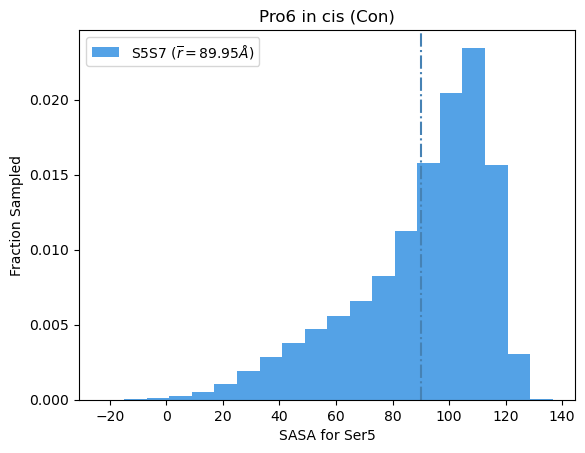

In [31]:
plt.hist((ser5_SASA_unphos_cistrans[ser5_SASA_unphos_cistrans['cis/trans/neither'] == 'cis'])['SA_00014'], bins=20, weights = (ser5_SASA_unphos_cistrans[ser5_SASA_unphos_cistrans['cis/trans/neither'] == 'cis'])['weights'], density=True , color="#0C7BDC", label=r"S5S7 ($\overline{r} = $"+"{}$\AA$)".format(round(mean_cis, 2)), alpha=0.7)

#plt.axvline(npmean, color='steelblue', ls='--')
plt.axvline(mean_cis, color='steelblue', ls='-.')
#plt.ylim([0, 0.45])
#plt.xlim([3,8])
# plt.text(15.5, 0.24, r"$\overline{r_{unphos}}=$" + str(round(pmean, 3)), fontsize=9, horizontalalignment='right')
# plt.text(15.5, 0.255, r"$\overline{r_{ununphos}}=$" + str(round(npmean, 2)), fontsize=9, horizontalalignment='right')

#plt.axvline(ctd['1-23'].mean(), color='k', linestyle='solid', linewidth=1, label = "CTD mean")
#plt.axvline(ctd_cisp['1-23'].mean(), color='k', linestyle='dotted', linewidth=1, label = "CTD unphos mean")
plt.ylabel('Fraction Sampled')
plt.xlabel('SASA for Ser5')
plt.title('Pro6 in cis (Con)')
plt.legend(loc="upper left", fontsize=10)
plt.show()

## Pro6 in trans

In [32]:
mean_trans = np.average((ser5_SASA_unphos_cistrans[ser5_SASA_unphos_cistrans['cis/trans/neither'] == 'trans'])['SA_00014'], weights=(ser5_SASA_unphos_cistrans[ser5_SASA_unphos_cistrans['cis/trans/neither'] == 'trans'])['weights'])

std_trans = np.sqrt(np.cov((ser5_SASA_unphos_cistrans[ser5_SASA_unphos_cistrans['cis/trans/neither'] == 'trans'])['SA_00014'], aweights=(ser5_SASA_unphos_cistrans[ser5_SASA_unphos_cistrans['cis/trans/neither'] == 'trans'])['weights']))

print("mean: {}".format(mean_trans))
print("std: {}".format(std_trans))

mean: 74.24494205029323
std: 27.268736377204934


In [35]:
# Define column names
columns = ['cis', 'trans']

# Create an empty DataFrame with 2 rows and 5 columns
SASA_all = pd.DataFrame(np.nan, index=range(nsim), columns=columns)
SASA_weights = pd.DataFrame(np.nan, index=range(nsim), columns=columns)

print(SASA_all)

   cis  trans
0  NaN    NaN
1  NaN    NaN
2  NaN    NaN
3  NaN    NaN
4  NaN    NaN
5  NaN    NaN
6  NaN    NaN
7  NaN    NaN
8  NaN    NaN
9  NaN    NaN


In [36]:
i = 0
for sim in SASA_sim_list:
    cis_true = ((sim['cis/trans/neither'] == 'cis')*sim['weights']).sum()
    trans_true = ((sim['cis/trans/neither'] == 'trans')*sim['weights']).sum()

    mean = sim['SA_00014'].mul((sim['cis/trans/neither'] == 'cis')*sim['weights'], 0).sum()/cis_true
    SASA_all.at[i, 'cis'] = mean
    SASA_weights.at[i, 'cis'] = cis_true
    mean = sim['SA_00014'].mul((sim['cis/trans/neither'] == 'trans')*sim['weights'], 0).sum()/trans_true
    SASA_all.at[i, 'trans'] = mean
    SASA_weights.at[i, 'trans'] = trans_true
    
    i += 1

In [37]:
mean_list = []
sem_list = []
for i in range(2):
    print(i)
    mean_list.append(weighted_mean_and_se(SASA_all.iloc[:,i].tolist(), SASA_weights.iloc[:,i].tolist())[0])
    sem_list.append(weighted_mean_and_se(SASA_all.iloc[:,i].tolist(), SASA_weights.iloc[:,i].tolist())[1])

0
1


In [38]:
df_with_mean = pd.concat([SASA_all, pd.DataFrame([mean_list], index=['mean'], columns=columns)])
SASA_all_final = pd.concat([df_with_mean, pd.DataFrame([sem_list], index=['sem'], columns=columns)])

In [40]:
SASA_all_final

,cis,trans
0,89.270232,71.855194
1,94.548251,77.696026
2,89.744406,75.331422
3,89.511146,71.396299
4,91.038015,72.245347
5,92.273338,71.819729
6,86.023452,71.868678
7,84.777204,75.611285
8,91.635994,77.644156
9,92.780902,76.611732


In [39]:
# Original data and weights
group1_data = SASA_all['cis']
group1_weights = SASA_weights['cis']

group2_data = SASA_all['trans']
group2_weights = SASA_weights['trans']

# Normalize the weights
group1_p = group1_weights / np.sum(group1_weights)
group2_p = group2_weights / np.sum(group2_weights)

# Calculate the observed difference in means
original_diff_means = mean_cis - mean_trans

num_iterations = 1000000

# Vectorized resampling
# Draws num_iterations samples of size len(data) in a single operation
resampled_g1 = np.random.choice(group1_data, size=(num_iterations, len(group1_data)), replace=True, p=group1_p)
resampled_g2 = np.random.choice(group2_data, size=(num_iterations, len(group2_data)), replace=True, p=group2_p)

# Calculate the mean for each resampled group along the rows (axis=1)
means_g1 = np.mean(resampled_g1, axis=1)
means_g2 = np.mean(resampled_g2, axis=1)

# Calculate the difference in means for all samples at once
diff_means_samples = means_g1 - means_g2

# Calculate the p-value
p_value = np.sum(np.abs(diff_means_samples) >= np.abs(original_diff_means)) / num_iterations

print(f"Original difference in means: {original_diff_means}")
print(f"Calculated P-value from vectorized permutation test: {p_value}")

Original difference in means: 15.709772806628607
Calculated P-value from vectorized permutation test: 0.505137


In [45]:
# Original data and weights
group1_data = SASA_all['cis']
group1_weights = SASA_weights['cis']

group2_data = SASA_all['trans']
group2_weights = SASA_weights['trans']

both_groups = pd.concat([group1_data, group2_data], ignore_index=True)
both_weights = pd.concat([group1_weights, group2_weights], ignore_index=True)

# Normalize the weights
group1_p = group1_weights / np.sum(group1_weights)
group2_p = group2_weights / np.sum(group2_weights)

both_p = both_weights / np.sum(both_weights)

# Calculate the observed statistic on the original data using the MEAN
original_diff_means = mean_cis - mean_trans


num_sims = 10
#sample 10000 times and calculate differences
numsample = 10000
diff_samples = [0]*numsample
diff_samples_larger = [0]*numsample
for sample in range(0,len(diff_samples)):
    # randomize means and weights arrays in the same order
    p = np.random.permutation(len(both_groups))
    random_both_groups = both_groups[p]
    random_weights = both_p[p]
    diff_samples[sample] = (np.average(random_both_groups[0:num_sims], weights=random_weights[0:num_sims]) 
             - np.average(random_both_groups[num_sims:num_sims 
                                                + num_sims], weights=random_weights[num_sims:num_sims 
                                                + num_sims]))
    #diff_samples[sample] = (np.mean(random_groups[0:num_sims]) 
    #         - np.mean(random_groups[num_sims:num_sims 
    #                                            + num_sims]))
    if diff_samples[sample] >= original_diff_means:
        diff_samples_larger[sample] = 1
    
# Calculate the p-value
p_value = (1 + np.sum(diff_samples_larger))/(numsample + 1)

print(f"Original difference in means: {original_diff_means}")
print(f"Calculated P-value from permutation test: {p_value}")

Original difference in means: 15.709772806628607
Calculated P-value from permutation test: 9.999000099990002e-05


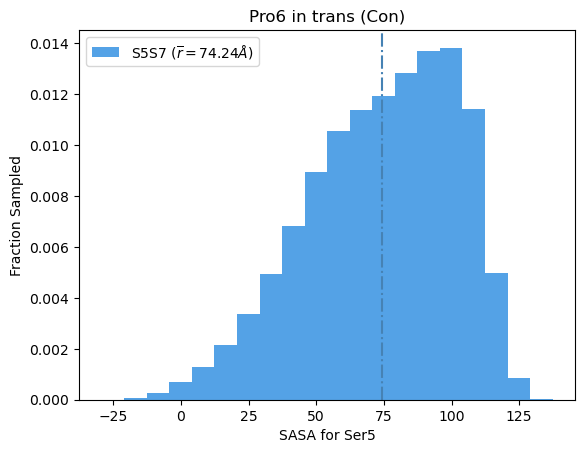

In [33]:
plt.hist((ser5_SASA_unphos_cistrans[ser5_SASA_unphos_cistrans['cis/trans/neither'] == 'trans'])['SA_00014'], bins=20, weights = (ser5_SASA_unphos_cistrans[ser5_SASA_unphos_cistrans['cis/trans/neither'] == 'trans'])['weights'], density=True , color="#0C7BDC", label=r"S5S7 ($\overline{r} = $"+"{}$\AA$)".format(round(mean_trans, 2)), alpha=0.7)

#plt.axvline(npmean, color='steelblue', ls='--')
plt.axvline(mean_trans, color='steelblue', ls='-.')
#plt.ylim([0, 0.45])
#plt.xlim([3,8])
# plt.text(15.5, 0.24, r"$\overline{r_{unphos}}=$" + str(round(pmean, 3)), fontsize=9, horizontalalignment='right')
# plt.text(15.5, 0.255, r"$\overline{r_{ununphos}}=$" + str(round(npmean, 2)), fontsize=9, horizontalalignment='right')

#plt.axvline(ctd['1-23'].mean(), color='k', linestyle='solid', linewidth=1, label = "CTD mean")
#plt.axvline(ctd_cisp['1-23'].mean(), color='k', linestyle='dotted', linewidth=1, label = "CTD unphos mean")
plt.ylabel('Fraction Sampled')
plt.xlabel('SASA for Ser5')
plt.title('Pro6 in trans (Con)')
plt.legend(loc="upper left", fontsize=10)
plt.show()

## cis and trans together

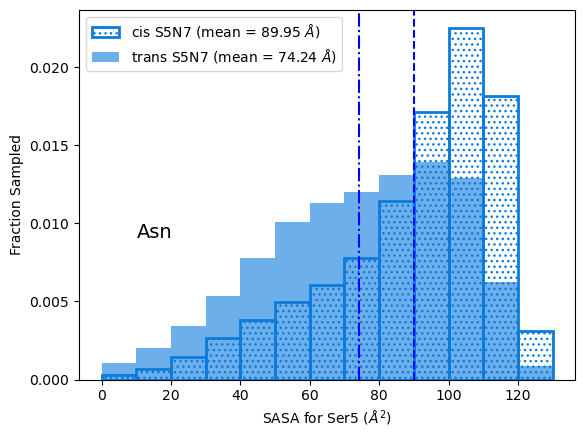

In [46]:
binedges = np.arange(0,135,10)

plt.hist((ser5_SASA_unphos_cistrans[ser5_SASA_unphos_cistrans['cis/trans/neither'] == 'cis'])['SA_00014'], bins=binedges, weights = (ser5_SASA_unphos_cistrans[ser5_SASA_unphos_cistrans['cis/trans/neither'] == 'cis'])['weights'], density=True , color="#0C7BDC", linewidth=2, fill=None, hatch='...', edgecolor="#0C7BDC", label=r"cis S5N7 (mean = "+"{} $\AA$)".format(round(mean_cis, 2)), alpha=1)

#plt.axvline(npmean, color='steelblue', ls='--')
plt.axvline(mean_cis, color='blue', ls='--')

plt.hist((ser5_SASA_unphos_cistrans[ser5_SASA_unphos_cistrans['cis/trans/neither'] == 'trans'])['SA_00014'], bins=binedges, weights = (ser5_SASA_unphos_cistrans[ser5_SASA_unphos_cistrans['cis/trans/neither'] == 'trans'])['weights'], density=True , color="#0C7BDC", label=r"trans S5N7 (mean = "+"{} $\AA$)".format(round(mean_trans, 2)), alpha=0.6)

#plt.axvline(npmean, color='steelblue', ls='--')
plt.axvline(mean_trans, color='blue', ls='-.')
#plt.ylim([0, 0.45])
#plt.xlim([3,8])
# plt.text(15.5, 0.24, r"$\overline{r_{unphos}}=$" + str(round(pmean, 3)), fontsize=9, horizontalalignment='right')
# plt.text(15.5, 0.255, r"$\overline{r_{ununphos}}=$" + str(round(npmean, 2)), fontsize=9, horizontalalignment='right')

#plt.axvline(ctd['1-23'].mean(), color='k', linestyle='solid', linewidth=1, label = "CTD mean")
#plt.axvline(ctd_cisp['1-23'].mean(), color='k', linestyle='dotted', linewidth=1, label = "CTD unphos mean")
plt.ylabel('Fraction Sampled')
plt.xlabel('SASA for Ser5 ($\AA^{2}$)')
#plt.title('Asparagine Unphosphorylated')
plt.legend(loc="upper left", fontsize=10)
plt.text(10, 0.01, 'Asn', fontsize=14, verticalalignment='top')
plt.show()